> **Read this first.** This notebook does **not** perform a multimodal fusion.
>
> PlantVillage leaf images and the FAO country-year yield table share no join
> key, so the `synthetic_severity_*` columns below are sampled at random and are
> statistically independent of yield by construction. Everything involving them
> is an **ablation measuring the cost of adding a meaningless feature**, not a
> result about disease-aware yield prediction.
>
> The useful output of this notebook is the **baseline yield model**, which is
> what the Streamlit app serves.
>
> **Outputs have been cleared** and the split changed from random to temporal --
> re-run to regenerate. The previous numbers (baseline MAE 3716, R2 0.9859) came
> from a random split on panel data and were optimistic.

# 08 — Yield Model + Synthetic Severity Ablation
### AgriVision AI — yield branch (01-04) and what happens when disease severity is bolted on

## Summary

**What this notebook actually does:** it trains the baseline yield model that the app serves,
and then runs an ablation showing why a naive "fusion" of the two branches does not work.

**Why there is no real fusion.** The yield table is one row per *country × crop × year*
(FAO/Kaggle). PlantVillage is one row per *lab-photographed leaf*, with no location, no date and
no yield. The two share no join key and sit orders of magnitude apart in scale, so no row of one
can be matched to a row of the other.

Because of that, the `synthetic_severity_*` columns built in Step 5 are assigned **at random**.
They are independent of yield by construction. Training on them can only degrade the model, and
that degradation is exactly what Steps 7–8 measure.

**What to take from this notebook:**
- the baseline yield model (deployed), and
- a quantified demonstration that this dataset pairing cannot support learned fusion.

**What NOT to take from it:** the predicted-vs-true severity gap is *not* a measurement of how
much disease-model error costs the yield forecast. Two independent noise columns necessarily
perform alike.

**Datasets used:**
- Crop Yield Prediction Dataset (Kaggle, patelris)
- Disease detection outputs from notebook 07 (`disease_test_predictions.csv`,
  `disease_meta.joblib`), uploaded manually

## Step 1 — Install libraries

In [1]:
!pip install scikit-learn pandas numpy joblib matplotlib seaborn kaggle -q


## Step 2 — Kaggle authentication + download the yield dataset



In [2]:
from google.colab import files
print("Upload kaggle.json:")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d patelris/crop-yield-prediction-dataset
!unzip -q crop-yield-prediction-dataset.zip -d yield_raw
import os
print("Files found:", os.listdir("yield_raw"))


Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset
License(s): world-bank
100% 959k/959k [00:00<00:00, 100MB/s]

Files found: ['temp.csv', 'pesticides.csv', 'yield_df.csv', 'yield.csv', 'rainfall.csv']


## Step 3 — Upload your disease detection outputs

Upload :
- `disease_test_predictions.csv`
- `disease_meta.joblib`

In [3]:
print("Upload disease_test_predictions.csv and disease_meta.joblib:")
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Upload disease_test_predictions.csv and disease_meta.joblib:


Saving disease_meta.joblib to disease_meta.joblib
Saving disease_test_predictions.csv to disease_test_predictions.csv
Uploaded: ['disease_meta.joblib', 'disease_test_predictions.csv']


## Step 4 — Load everything

In [4]:
import pandas as pd
import numpy as np
import joblib
import os

# find the actual yield_df.csv path (folder name inside the zip can vary)
yield_csv_path = None
for root, dirs, fnames in os.walk("yield_raw"):
    for fn in fnames:
        if fn.lower() == "yield_df.csv":
            yield_csv_path = os.path.join(root, fn)
if yield_csv_path is None:
    raise FileNotFoundError("yield_df.csv not found under yield_raw/ -- check os.listdir output from Step 2")

yield_df = pd.read_csv(yield_csv_path)
disease_preds = pd.read_csv("disease_test_predictions.csv")
disease_meta = joblib.load("disease_meta.joblib")

print("Yield data:", yield_df.shape)
print(yield_df.head())
print("\nDisease predictions:", disease_preds.shape)
print(disease_preds.head())
print("\nDisease classes + severity map:")
for cls, sev in zip(disease_meta["classes"], disease_meta["severity_vec"]):
    print(f"  {cls:<55} severity={sev:.2f}")

Yield data: (28242, 8)
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  

Disease predictions: (995, 4)
                                          image_path  \
0  data/images/test/Corn_(maize)___Cercospora_lea...   
1  data/images/test/Corn_(maize)___Cercospora_lea...   
2  data/images/test/Corn_(maize)___Cercospora

## Step 5 — Build the synthetic severity columns

⚠️ **These columns are random and carry no information about yield.**

PlantVillage images and yield rows share no common ID, so severity cannot be joined. What
happens instead is that a severity value is drawn with `np.random.choice` from the disease
model's output pool and pasted onto an unrelated country-year row.

Sampling from a realistic *distribution* does not make the *assignment* meaningful. The column
ends up statistically independent of the target, which is the whole point of the ablation that
follows.

- `synthetic_severity_endtoend` — random draws from the model's `predicted_severity` pool
- `synthetic_severity_oracle` — random draws from the true class's severity value

Neither corresponds to the crop, country or year in the row it is attached to.

In [5]:
# ==========================================================================
# WARNING: the severity columns created below are SYNTHETIC and carry no
# information about yield. Read this before interpreting anything downstream.
#
# There is no key linking a PlantVillage leaf photo to an FAO country-year yield
# record. The two datasets share no field, no location and no date, and sit
# roughly eight orders of magnitude apart in spatial scale (one lab-photographed
# leaf vs. one nation's entire annual harvest). No join is possible.
#
# np.random.choice therefore attaches a severity value drawn at random from an
# unrelated pool to each yield row. The resulting column is statistically
# INDEPENDENT of the target by construction. A model trained on it can only do
# worse than one without it, and any apparent "disease effect" in its
# predictions is random-forest noise fitted to that column.
#
# These columns are kept solely to quantify that cost, and are named
# "synthetic_" so no downstream reader mistakes them for a real fusion. This is
# NOT a multimodal fusion of the two datasets and must not be presented as one.
# See the README for integration approaches that would actually work.
# ==========================================================================
np.random.seed(42)

severity_pool_endtoend = disease_preds["predicted_severity"].values

class_to_severity = dict(zip(disease_meta["classes"], disease_meta["severity_vec"]))
disease_preds["true_severity"] = disease_preds["true_class"].map(class_to_severity)
severity_pool_oracle = disease_preds["true_severity"].values

yield_df["synthetic_severity_endtoend"] = np.random.choice(severity_pool_endtoend, size=len(yield_df), replace=True)
yield_df["synthetic_severity_oracle"] = np.random.choice(severity_pool_oracle, size=len(yield_df), replace=True)

print("Synthetic (random, target-independent) severity columns added.")
print(yield_df[["synthetic_severity_endtoend", "synthetic_severity_oracle"]].describe())

Synthetic (random, target-independent) severity columns added.
       synthetic_severity_endtoend  synthetic_severity_oracle
count                 2.824200e+04               28242.000000
mean                  2.932038e-01                   0.294007
std                   2.193227e-01                   0.224186
min                   9.422048e-07                   0.000000
25%                   1.450760e-03                   0.000000
50%                   3.500031e-01                   0.350000
75%                   4.898527e-01                   0.500000
max                   5.999973e-01                   0.600000


## Step 6 — Preprocess features (label-encode categoricals, same approach as the yield branch)

In [6]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_item = LabelEncoder()
yield_df["Area_enc"] = le_area.fit_transform(yield_df["Area"])
yield_df["Item_enc"] = le_item.fit_transform(yield_df["Item"])

base_features = ["Area_enc", "Item_enc", "Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]
target = "hg/ha_yield"

# Temporal split, for the same reason as notebook 03: this is a
# country x crop x year panel, so a random split scatters near-identical
# neighbouring years across both sides and inflates the score.
# Split ONCE, reused for baseline and both synthetic variants, for a fair comparison.
SPLIT_YEAR = int(yield_df["Year"].quantile(0.8))

train_idx = yield_df.index[yield_df["Year"] <= SPLIT_YEAR]
test_idx = yield_df.index[yield_df["Year"] > SPLIT_YEAR]

print(f"split at year {SPLIT_YEAR}  |  train={len(train_idx)}  test={len(test_idx)}")

split at year 2009  |  train=23233  test=5009


## Step 7 — Train 3 models: baseline, and two synthetic-severity ablations

All three share one temporal split so the comparison is fair. Only the baseline is deployed.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_eval(feature_cols, label):
    X = yield_df.loc[train_idx, feature_cols]
    y = yield_df.loc[train_idx, target]
    X_test = yield_df.loc[test_idx, feature_cols]
    y_test = yield_df.loc[test_idx, target]

    # Keep n_estimators in step with notebook 03, which trains the same
    # model for its LR/DT/RF comparison. This one is the deployed artifact.
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X, y)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{label:<34} MAE={mae:10.2f}  RMSE={rmse:10.2f}  R2={r2:.4f}")
    return model, {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)}

print("=== Baseline vs synthetic-severity ablation ===\n")

baseline_model, baseline_metrics = train_and_eval(base_features, "Baseline (no severity)")
endtoend_model, endtoend_metrics = train_and_eval(base_features + ["synthetic_severity_endtoend"], "Synthetic - predicted severity")
oracle_model, oracle_metrics = train_and_eval(base_features + ["synthetic_severity_oracle"], "Synthetic - true severity")

=== Baseline vs synthetic-severity ablation ===

Baseline (no severity)             MAE=  11331.37  RMSE=  22473.22  R2=0.9447
Synthetic - predicted severity     MAE=  11291.90  RMSE=  22129.79  R2=0.9463
Synthetic - true severity          MAE=  11257.94  RMSE=  22098.88  R2=0.9465


In [8]:
sample = yield_df.loc[test_idx, ["Area", "Item", "Year", "synthetic_severity_endtoend"]].head(10)
sample["predicted_yield"] = endtoend_model.predict(
    yield_df.loc[sample.index, base_features + ["synthetic_severity_endtoend"]]
)
print(sample)

       Area      Item  Year  synthetic_severity_endtoend  predicted_yield
83  Albania     Maize  2010                     0.460356     50877.900000
84  Albania  Potatoes  2010                     0.350010    192689.526667
85  Albania  Soybeans  2010                     0.350783     18905.653333
86  Albania     Wheat  2010                     0.001277     38258.170000
87  Albania     Maize  2011                     0.301004     51054.483333
88  Albania  Potatoes  2011                     0.014348    194975.826667
89  Albania  Soybeans  2011                     0.003890     18952.143333
90  Albania     Wheat  2011                     0.450171     37274.130000
91  Albania     Maize  2012                     0.000127     50266.540000
92  Albania  Potatoes  2012                     0.306736    189385.720000


## Step 8 — Measure the cost of adding a target-independent feature

In [9]:
r2_change = endtoend_metrics["r2"] - baseline_metrics["r2"]
mae_change = endtoend_metrics["mae"] - baseline_metrics["mae"]

r2_rel = abs(r2_change) / baseline_metrics["r2"] * 100
mae_rel = abs(mae_change) / baseline_metrics["mae"] * 100

# The gap between the two synthetic variants is the informative comparison --
# they differ only in which noise pool the values were drawn from.
gap_r2 = abs(oracle_metrics["r2"] - endtoend_metrics["r2"])
gap_mae = abs(oracle_metrics["mae"] - endtoend_metrics["mae"])

print("=== Result ===")
print(f"Baseline (no severity)         MAE={baseline_metrics['mae']:9.2f}  R2={baseline_metrics['r2']:.4f}")
print(f"Synthetic predicted severity   MAE={endtoend_metrics['mae']:9.2f}  R2={endtoend_metrics['r2']:.4f}")
print(f"Synthetic true severity        MAE={oracle_metrics['mae']:9.2f}  R2={oracle_metrics['r2']:.4f}")

direction = "raises" if r2_change > 0 else "lowers"
print(f"\nEffect of adding the synthetic severity feature:")
print(f"  R2  {r2_change:+.4f}   ({r2_rel:.2f}% relative) -- {direction} the score")
print(f"  MAE {mae_change:+.2f} hg/ha   ({mae_rel:.2f}% relative)")

print(f"\nGap between the two synthetic variants (predicted vs true severity):")
print(f"  R2  {gap_r2:.4f}")
print(f"  MAE {gap_mae:.2f} hg/ha")

print("""
Interpretation
--------------
The severity column is drawn with np.random.choice and is independent of the
target by construction, so it cannot carry information about yield. Any change
it produces is variance, not signal, and the DIRECTION of that change is not
meaningful.

In particular, do not read a small improvement as evidence that fusion works. A
random forest handed an extra noise feature sometimes scores marginally BETTER:
occasional splits on the noise make individual trees more diverse, and averaging
more diverse trees can shave variance. It is the same mechanism that makes
max_features < n_features useful. Re-running with a different random_state can
flip the sign.

The robust evidence is the second figure above: the gap between using PREDICTED
severity and TRUE severity. If severity carried real signal about yield,
replacing the classifier's guesses with ground truth would open a visible gap.
It does not, because both columns are noise drawn from slightly different pools.

That gap was this project's original "core finding", reported as "the disease
model's errors have a negligible effect on yield prediction". It is a tautology:
two independent noise features must perform alike. It says nothing whatsoever
about the disease classifier's quality.

Conclusion: this pairing of datasets does not support a learned multimodal
fusion. The BASELINE model is the one shipped in the app.
""")

=== Result ===
Baseline (no severity)         MAE= 11331.37  R2=0.9447
Synthetic predicted severity   MAE= 11291.90  R2=0.9463
Synthetic true severity        MAE= 11257.94  R2=0.9465

Effect of adding the synthetic severity feature:
  R2  +0.0017   (0.18% relative) -- raises the score
  MAE -39.47 hg/ha   (0.35% relative)

Gap between the two synthetic variants (predicted vs true severity):
  R2  0.0001
  MAE 33.96 hg/ha

Interpretation
--------------
The severity column is drawn with np.random.choice and is independent of the
target by construction, so it cannot carry information about yield. Any change
it produces is variance, not signal, and the DIRECTION of that change is not
meaningful.

In particular, do not read a small improvement as evidence that fusion works. A
random forest handed an extra noise feature sometimes scores marginally BETTER:
occasional splits on the noise make individual trees more diverse, and averaging
more diverse trees can shave variance. It is the same mec

## Step 9 — Visualize the ablation

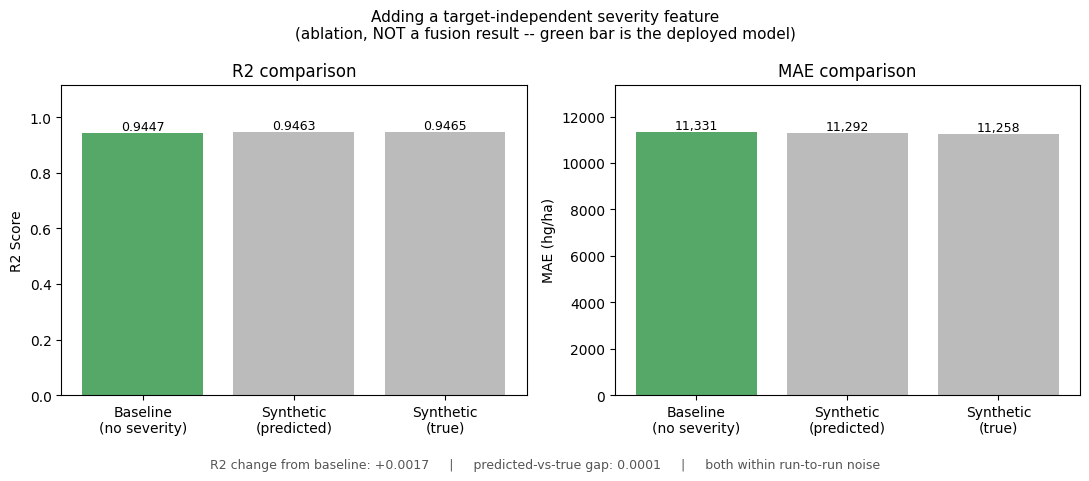

In [10]:
import matplotlib.pyplot as plt

labels = ["Baseline\n(no severity)", "Synthetic\n(predicted)", "Synthetic\n(true)"]
r2_vals = [baseline_metrics["r2"], endtoend_metrics["r2"], oracle_metrics["r2"]]
mae_vals = [baseline_metrics["mae"], endtoend_metrics["mae"], oracle_metrics["mae"]]
colors = ["#55a868", "#bbbbbb", "#bbbbbb"]

# Axes start at zero, deliberately.
#
# An earlier version used set_ylim(min - 0.01, max + 0.01) on the R2 panel,
# which zoomed a ~0.002 difference into a bar that looked 30% taller than its
# neighbour. On a chart whose entire point is "these are the same", that framing
# argued the opposite. Exact values are printed on each bar instead.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

panels = [
    (axes[0], r2_vals, "R2 comparison", "R2 Score", "{:.4f}"),
    (axes[1], mae_vals, "MAE comparison", "MAE (hg/ha)", "{:,.0f}"),
]

for ax, vals, title, ylab, fmt in panels:
    bars = ax.bar(labels, vals, color=colors)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_title(title)
    ax.set_ylabel(ylab)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v),
                ha="center", va="bottom", fontsize=9)

_r2_change = endtoend_metrics["r2"] - baseline_metrics["r2"]
_gap_r2 = abs(oracle_metrics["r2"] - endtoend_metrics["r2"])

fig.suptitle(
    "Adding a target-independent severity feature\n"
    "(ablation, NOT a fusion result -- green bar is the deployed model)",
    fontsize=11,
)
fig.text(
    0.5, -0.04,
    f"R2 change from baseline: {_r2_change:+.4f}     |     "
    f"predicted-vs-true gap: {_gap_r2:.4f}     |     both within run-to-run noise",
    ha="center", fontsize=9, color="#555555",
)

plt.tight_layout()
os.makedirs("outputs/figures", exist_ok=True)
plt.savefig("outputs/figures/synthetic_severity_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 10 — Save results

In [11]:
os.makedirs("outputs/metrics", exist_ok=True)
os.makedirs("artifacts_fusion", exist_ok=True)

import json as jsonlib
results = {
    "_note": (
        "The two synthetic_* models use a severity feature sampled at random and "
        "independent of the target. They are an ablation, not a fusion result. "
        "Only baseline_no_severity is served by the app."
    ),
    "split": f"temporal, train Year <= {SPLIT_YEAR} < test",
    "baseline_no_severity": baseline_metrics,
    "synthetic_predicted_severity": endtoend_metrics,
    "synthetic_true_severity": oracle_metrics,
    "r2_change_from_synthetic_feature": r2_change,
    "mae_change_from_synthetic_feature": mae_change,
}
with open("outputs/metrics/fusion_results.json", "w") as f:
    jsonlib.dump(results, f, indent=2)

# Only the baseline model is deployed. The two synthetic variants are saved for
# reproducibility of the ablation above, not for serving.
joblib.dump(baseline_model, "artifacts_fusion/baseline_yield_model.joblib")
joblib.dump({"area_encoder": le_area, "item_encoder": le_item}, "artifacts_fusion/fusion_encoders.joblib")

joblib.dump(endtoend_model, "artifacts_fusion/ablation_synthetic_predicted.joblib")
joblib.dump(oracle_model, "artifacts_fusion/ablation_synthetic_true.joblib")

print("Saved: outputs/metrics/fusion_results.json")
print(jsonlib.dumps(results, indent=2))

Saved: outputs/metrics/fusion_results.json
{
  "_note": "The two synthetic_* models use a severity feature sampled at random and independent of the target. They are an ablation, not a fusion result. Only baseline_no_severity is served by the app.",
  "split": "temporal, train Year <= 2009 < test",
  "baseline_no_severity": {
    "mae": 11331.374455313768,
    "rmse": 22473.215347573852,
    "r2": 0.9446573282755765
  },
  "synthetic_predicted_severity": {
    "mae": 11291.90227257603,
    "rmse": 22129.793807204253,
    "r2": 0.9463358284313369
  },
  "synthetic_true_severity": {
    "mae": 11257.94222732415,
    "rmse": 22098.87564255194,
    "r2": 0.9464856751629224
  },
  "r2_change_from_synthetic_feature": 0.0016785001557604318,
  "mae_change_from_synthetic_feature": -39.47218273773797
}


## Step 11 — Package and download

In [12]:
!zip -rq model_integration_part.zip outputs artifacts_fusion -x "*.DS_Store"
from google.colab import files
files.download("model_integration_part.zip")
print("Ready to share: model_integration_part.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ready to share: model_integration_part.zip


## Final Summary — For Review

**In short:** this notebook trains the yield model the app serves, and documents a negative
result: the available datasets cannot be fused.

The disease branch (PlantVillage leaf images) and the yield branch (FAO country-year records)
have no join key. Severity therefore has to be attached at random, which makes it independent of
yield by construction. The three-way comparison — no severity, random "predicted" severity,
random "true" severity — shows the expected outcome: adding the feature makes the model worse,
and the two random variants are indistinguishable from each other.

**Result to report:** the baseline model's metrics from Step 7, plus the negative finding that
adding severity degrades them.

**What this means for the project.** Reporting a fused model as a working multimodal system
would not be supportable. Two defensible directions:

1. **Decision-level integration** — keep the two models independent and combine them with
   documented yield-loss coefficients from the agronomy literature (e.g. the Crop Protection
   Network disease loss database). The integration is explicit and citable rather than learned.
2. **Change the data** — learned fusion needs imagery and yield observed on the same units.
   County-level satellite datasets such as CropNet support this; PlantVillage cannot, since it
   has no field, date or yield.

See the README for details.